<a href="https://colab.research.google.com/github/dhakadprashant720-cloud/fake_review_detection_project/blob/master/fake_reviews_model_build.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Import libraries, load data, and display the first few rows of the DataFrame.
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('preprocessed_fake_review_data.csv')
df.head()

,label,text
0,1,love well made sturdi comfort love veri pretti
1,1,love great upgrad origin mine coupl year
2,1,thi pillow save back love look feel pillow
3,1,miss inform use great product price
4,1,veri nice set good qualiti set two month


<!-- Section: Split Data -->
# split data

In [3]:
# Assign features (text) to X and target (label) to y.
X = df['text']
y = df['label']

In [4]:
# Initialize and fit a TF-IDF Vectorizer to transform text data.
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [5]:
# Print the shape of the transformed feature matrix X.
print(X.shape)

(40431, 5000)


In [6]:
# Print the transformed feature matrix X (sparse matrix representation).
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 948159 stored elements and shape (40431, 5000)>
  Coords	Values
  (0, 2624)	0.436866337626087
  (0, 4849)	0.2628048969002514
  (0, 2649)	0.3450918619827274
  (0, 4266)	0.4184445370146403
  (0, 854)	0.3694417178819389
  (0, 4733)	0.3991825802079439
  (0, 3346)	0.3873799816682399
  (1, 2624)	0.1886911652886036
  (1, 1929)	0.18934109042620925
  (1, 4681)	0.5593049812515177
  (1, 3062)	0.43056591374856173
  (1, 2789)	0.480811258304889
  (1, 986)	0.34421894691351895
  (1, 4971)	0.2840253121754567
  (2, 2624)	0.14372100363179474
  (2, 4448)	0.15639438912227469
  (2, 3217)	0.8149358445071414
  (2, 3766)	0.35704196309807484
  (2, 291)	0.2550409255639465
  (2, 2610)	0.1942654950179375
  (2, 1614)	0.24596893670454972
  (3, 1929)	0.22849485246633358
  (3, 2800)	0.5603228913884096
  (3, 2238)	0.5617597836165477
  (3, 4698)	0.2640034550694301
  :	:
  (40430, 4068)	0.05544819452805561
  (40430, 2977)	0.05344158128579014
  (40430, 3661)	0.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
import numpy as np

class MyLogisticRegression:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        y = np.asarray(y)

        self.m, self.n = X.shape

        self.W = np.zeros(self.n)
        self.b = 0

        for i in range(self.iterations):
            linear = X.dot(self.W) + self.b
            y_pred = self._sigmoid(linear)

            dW = (1/self.m) * X.T.dot(y_pred - y)
            db = (1/self.m) * np.sum(y_pred - y)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            if i % 100 == 0:
                y_pred_clipped = np.clip(y_pred, 1e-9, 1 - 1e-9)
                cost = -np.mean(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
                print(f"iteration {i}, cost: {cost}")

    #  NEW FUNCTION (confidence)
    def predict_proba(self, X):
        linear = X.dot(self.W) + self.b
        y_pred = self._sigmoid(linear)
        return y_pred

    #  UPDATED predict function
    def predict(self, X):
        linear = X.dot(self.W) + self.b
        y_pred = self._sigmoid(linear)

        class_pred = (y_pred >= 0.5).astype(int)

        return class_pred, y_pred   #  both output

In [9]:
model = MyLogisticRegression(lr=0.1, iterations=10000)
model.fit(X_train, y_train)

iteration 0, cost: 0.6931471805599453
iteration 100, cost: 0.6880792575730326
iteration 200, cost: 0.6831906999683451
iteration 300, cost: 0.6784605664239346
iteration 400, cost: 0.6738809049935698
iteration 500, cost: 0.6694443020689339
iteration 600, cost: 0.6651437910106687
iteration 700, cost: 0.6609728279000919
iteration 800, cost: 0.6569252672152657
iteration 900, cost: 0.6529953376051358
iteration 1000, cost: 0.6491776181632752
iteration 1100, cost: 0.6454670154928622
iteration 1200, cost: 0.6418587417641883
iteration 1300, cost: 0.6383482938938385
iteration 1400, cost: 0.634931433918141
iteration 1500, cost: 0.6316041705901155
iteration 1600, cost: 0.6283627421966554
iteration 1700, cost: 0.625203600569041
iteration 1800, cost: 0.6221233962432889
iteration 1900, cost: 0.6191189647158064
iteration 2000, cost: 0.6161873137330608
iteration 2100, cost: 0.613325611550477
iteration 2200, cost: 0.610531176094691
iteration 2300, cost: 0.6078014649639665
iteration 2400, cost: 0.60513406

In [13]:
from sklearn.metrics import accuracy_score

y_pred_classes,_ = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))

Accuracy: 0.8043773958204525


In [14]:
from sklearn.metrics import confusion_matrix

y_pred_classes,_ = model.predict(X_test)

confusion_matrix(y_test, y_pred_classes)



array([[3471,  598],
       [ 984, 3034]])

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print("Precision:", precision_score(y_test, y_pred_classes))
print("Recall:", recall_score(y_test, y_pred_classes))
print("F1 Score:", f1_score(y_test, y_pred_classes))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

Accuracy: 0.8043773958204525
Precision: 0.835352422907489
Recall: 0.7551020408163265
F1 Score: 0.793202614379085
Confusion Matrix:
 [[3471  598]
 [ 984 3034]]


In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

Accuracy: 0.8043773958204525
              precision    recall  f1-score   support

           0       0.78      0.85      0.81      4069
           1       0.84      0.76      0.79      4018

    accuracy                           0.80      8087
   macro avg       0.81      0.80      0.80      8087
weighted avg       0.81      0.80      0.80      8087



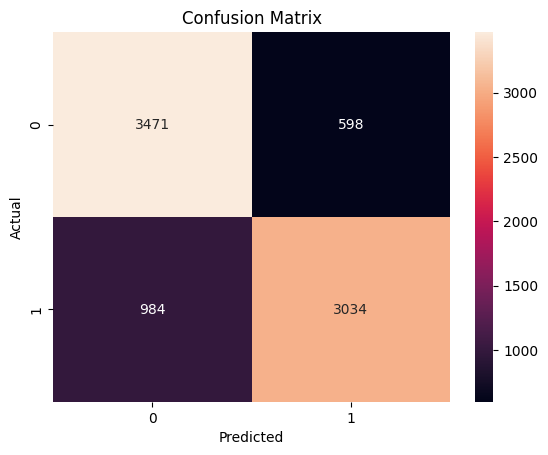

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# heatmap plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# z = np.linspace(-10, 10, 100)
# sig = 1 / (1 + np.exp(-z))

# plt.figure()
# plt.plot(z, sig)

# plt.title("Sigmoid Curve")
# plt.xlabel("z")
# plt.ylabel("Probability")

# plt.show()

In [ ]:
y_pred, y_prob = model.predict(X_test)

In [ ]:
print("Predictions (0/1):", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions (0/1): [1 1 0 1 0 0 1 0 0 0]
Probabilities: [0.86026273 0.76001031 0.32026227 0.66195044 0.30340639 0.18579562
 0.70361577 0.39602854 0.44450731 0.23891931]


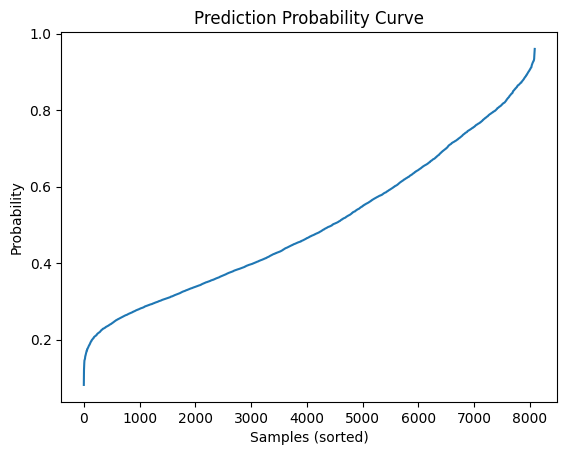

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# sort for smooth curve
sorted_prob = np.sort(y_prob)

plt.figure()
plt.plot(sorted_prob)

plt.title("Prediction Probability Curve")
plt.xlabel("Samples (sorted)")
plt.ylabel("Probability")

plt.show()

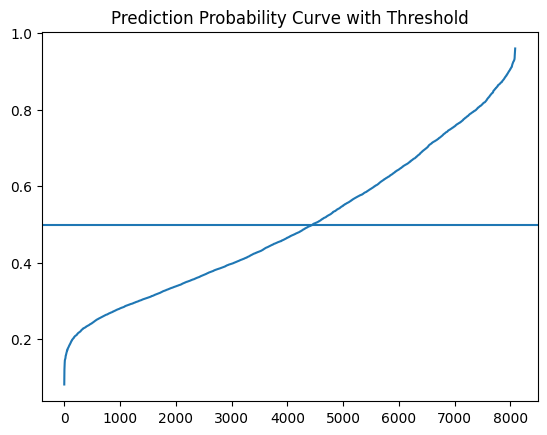

In [ ]:
plt.figure()
plt.plot(sorted_prob)

# threshold line
plt.axhline(y=0.5)

plt.title("Prediction Probability Curve with Threshold")
plt.show()

In [ ]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf_vec.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [ ]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("tfidf_vec.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>